In [1]:
!pip install tensorflow


Defaulting to user installation because normal site-packages is not writeable


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_2 (SimpleRNN)    (None, 10)                120       
                                                                 
 dense_2 (Dense)             (None, 1)                 11        
                                                                 
Total params: 131
Trainable params: 131
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
50/50 [==============================] - 1s 5ms/step - loss: 0.1696 - val_loss: 0.0850
Epoch 2/50
50/50 [==============================] - 0s 2ms/step - loss: 0.0427 - val_loss: 0.0150
Epoch 3/50
50/50 [==============================] - 0s 2ms/step - loss: 0.0079 - val_loss: 0.0028
Epoch 4/50
50/50 [==============================] - 0s 2ms/step - loss: 0.0020 - val_loss: 0.0010
Epoch 5/50
50/50 [==============================] - 0s 2ms/s

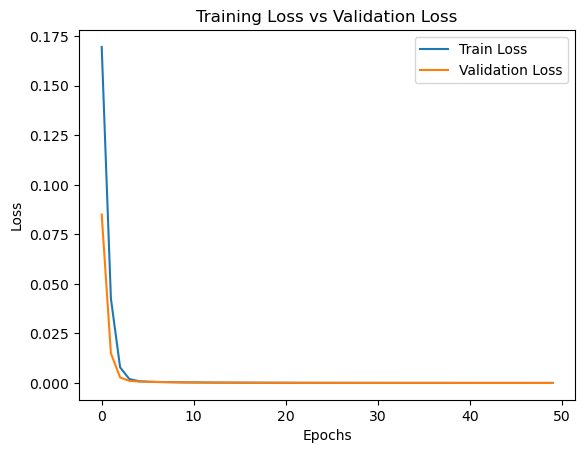

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt 

def generate_sequence(seq_length=5, num_samples=1000):
    X, y = [], []
    for _ in range(num_samples):  
        seq = np.random.rand(seq_length)
        X.append(seq)
        y.append(seq[-1] + 0.1) 
    return np.array(X), np.array(y)

seq_length = 5
X, y = generate_sequence(seq_length)
X = X.reshape((X.shape[0], seq_length, 1))

split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

model = Sequential([
    SimpleRNN(10, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

test_loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")

sample_input = np.array([0.1, 0.2, 0.3, 0.4, 0.5]).reshape(1, seq_length, 1)
predicted_value = model.predict(sample_input)
print(f"Predicted next value: {predicted_value}")

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss') # Fixed label - to =
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss vs Validation Loss') # Fixed .tittle to .title
plt.show()